In [3]:
pip install pulp pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("supply_chain_data.csv")

# View first rows
print(df.head())

  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

In [2]:
# Select required columns
data = df[[
    'Supplier name',
    'Location',
    'Costs',
    'Availability',
    'Order quantities'
]]

print(data.head())

  Supplier name Location       Costs  Availability  Order quantities
0    Supplier 3   Mumbai  187.752075            55                96
1    Supplier 3   Mumbai  503.065579            95                37
2    Supplier 1   Mumbai  141.920282            34                88
3    Supplier 5  Kolkata  254.776159            68                59
4    Supplier 1    Delhi  923.440632            26                56


In [4]:
import pulp

# Create Linear Programming model
model = pulp.LpProblem(
    "Supply_Chain_Optimization",
    pulp.LpMinimize
)

In [5]:
# Create decision variables

routes = pulp.LpVariable.dicts(
    "Route",
    (
        (i)
        for i in data.index
    ),
    lowBound=0,
    cat='Continuous'
)

In [6]:
model += pulp.lpSum(
    routes[i] * data.loc[i, 'Costs']
    for i in data.index
)

In [7]:
# Supply constraints

for i in data.index:
    model += (
        routes[i]
        <= data.loc[i, 'Availability']
    )

In [8]:
# Demand constraints

total_demand = data['Order quantities'].sum()

model += (
    pulp.lpSum(routes[i] for i in data.index)
    >= total_demand
)

In [9]:
# Solve model

model.solve()

print("Status:", pulp.LpStatus[model.status])

Status: Infeasible


In [13]:
# Results

results = []
for i in data.index:
    quantity = routes[i].varValue
    if quantity > 0:
        results.append({
            'Supplier': data.loc[i, 'Supplier name'],
            'Location': data.loc[i, 'Location'],
            'Cost': data.loc[i, 'Costs'],
            'Optimized Quantity': quantity
        })
results_df = pd.DataFrame(results)
print(results_df)
print("\nMinimum Total Cost = ", pulp.value(model.objective))

      Supplier Location        Cost  Optimized Quantity
0   Supplier 3   Mumbai  187.752075                55.0
1   Supplier 3   Mumbai  503.065579                95.0
2   Supplier 1   Mumbai  141.920282                34.0
3   Supplier 5  Kolkata  254.776159                68.0
4   Supplier 1    Delhi  923.440632                26.0
..         ...      ...         ...                 ...
95  Supplier 4   Mumbai  778.864241                65.0
96  Supplier 3   Mumbai  188.742141                29.0
97  Supplier 4   Mumbai  540.132423                56.0
98  Supplier 5  Chennai  882.198864                43.0
99  Supplier 2  Chennai  210.743009                17.0

[100 rows x 4 columns]

Minimum Total Cost =  2621863.4560482567


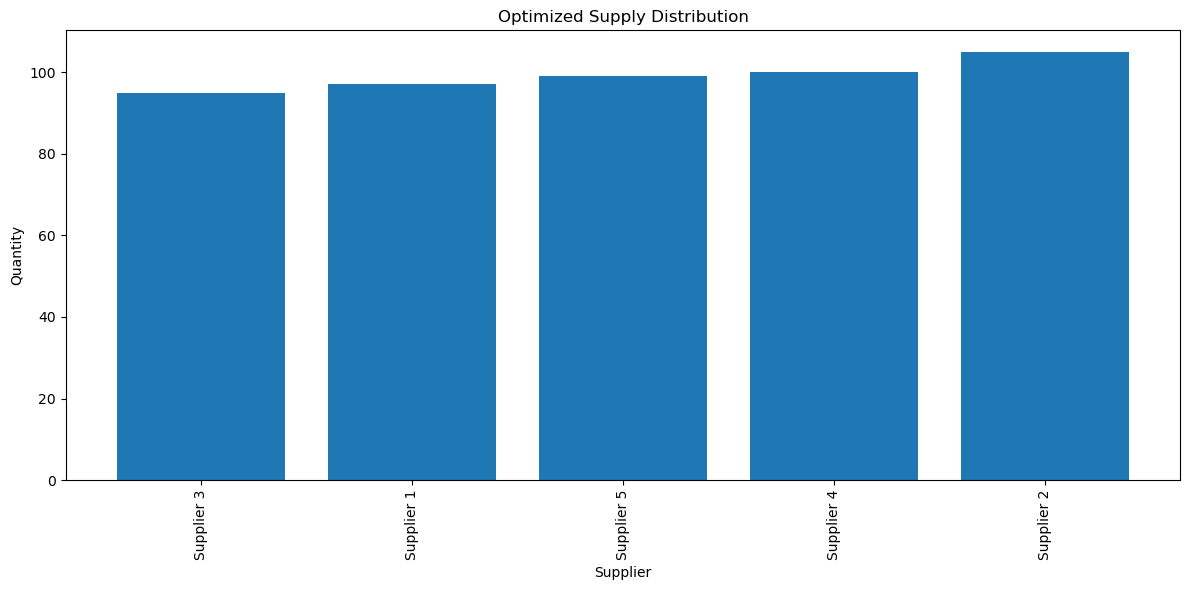

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(
    results_df['Supplier'],
    results_df['Optimized Quantity']
)
plt.xticks(rotation=90)
plt.title("Optimized Supply Distribution")
plt.ylabel("Quantity")
plt.xlabel("Supplier")
plt.tight_layout()
plt.show()